# Pruning Demo

In this demo we will show you how to: 
* Use the pruning functionality in `SymbolicModel` to restrict output dimensions of a PyTorch MLP
* Set up a pruning schedule and train
* Perform symbolic regression on a pruned MLP

## Pruning Background

For interpretability purposes, it is good to reduce the dimensionality of deep learning models. High-dimensional representations often entangle multiple features, making it difficult to extract clear, human-understandable relationships. By encouraging a sparse representation, we encourage the network to compress information into a smaller set of meaningful components. This may also make symbolic regression possible on these models.

The SymTorch pruning class allows you to dynamically reduce the output dimensionality of MLPs by zero-masking the unimportant dimensions.

**Important dimensions**: The dimensions that the model uses the most in predicting the output. These would vary most with differences in the input. Hence we choose the important dimensions as the ones with the highest standard deviation across the datapoints. 

We pass some input data through the model (usually a subset of the validation set) and analyse the outputs of the MLP. We choose the output dimensions that have the highest standard deviation across the datapoints, as shown below. 

<img src="../_static/choosing_important_dims.png" width="450" height="300">

## Wrapping a PyTorch model
Create a simple PyTorch model.

In [1]:
import torch
import numpy as np
import torch.nn as nn

class MLP(nn.Module):
    """
    Simple MLP.
    """
    def __init__(self, input_dim, output_dim, hidden_dim):
        super(MLP, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.mlp(x)

class SimpleModel(nn.Module):
    """
    Model with MLP f_net and linear g_net.
    """
    def __init__(self, input_dim, output_dim, output_dim_f=32, hidden_dim=128):
        super(SimpleModel, self).__init__()

        self.f_net = MLP(input_dim, output_dim_f, hidden_dim)
        # g is linear - only learns to combine the 2 pruned outputs from f
        self.g_net = nn.Linear(output_dim_f, output_dim)  # Will use first 2 dims of f after pruning

    def forward(self, x):
        x = self.f_net(x)
        x = self.g_net(x)
        return x

Train the model on some data. We have a composite function $y=g(f(\mathbf{x}))$.

$$
\begin{aligned}
& f_0 = x_0^2\\
& f_1 = \sin{x_4}
\end{aligned}
$$
and $g$ is just a linear transformation of $f_0$ and $f_1$

$$
g(\mathbf{f}) = 2.5f_0 -1.3f_1
$$

In [2]:
import numpy as np

# Make the dataset 
x = np.array([np.random.uniform(0, 1, 10_000) for _ in range(5)]).T

def f_func(x):
    f0 = x[:, 0]**2 
    f1 = np.sin(x[:, 4])  
    return np.stack([f0, f1], axis=1)

def g_func(f_output):
    a, b = 2.5, -1.3  
    return a * f_output[:, 0] + b * f_output[:, 1]

# Generate ground truth data
f_true = f_func(x)
y = g_func(f_true)

noise = np.array([np.random.normal(0, 0.05*np.std(y)) for _ in range(len(y))])
y = y + noise 

We need to set up the pruning model.

In [3]:
from symtorch import SymbolicModel

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [6]:
# Create model with pruning for f, linear g_net
model = SimpleModel(input_dim=x.shape[1], output_dim=1, output_dim_f=32)
model.f_net = SymbolicModel(model.f_net, block_name="f_net")

# Set up pruning
epochs = 100
batch_size = 32 
steps_per_epoch = x.shape[0]/batch_size
total_steps = epochs * steps_per_epoch
model.f_net.setup_pruning(initial_dim=32, 
                          target_dim=2, #dims at the end of pruning
                          end_step_frac=0.5, #when to finish pruning eg. ~50% of the way through training 
                          decay_rate='exp',
                          total_steps=int(total_steps))

✅ Pruning successfully set up for block f_net.
   Initial dimensions: 32
   Target dimensions: 2
   Total steps: 31250
   Pruning will complete at step 15625


## Training our model and dynamically reducing dimensionality

In [7]:
# Set up training

import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

def train_model(model, dataloader, X_val, opt, criterion, epochs=100):
    """
    Train model with MLP f (with pruning) and linear g_net.
    
    Args:
        model: PyTorch model to train
        dataloader: DataLoader for training data
        X_val, y_val: Validation data for pruning
        opt: Optimizer
        criterion: Loss function
        epochs: Number of training epochs
        
    Returns:
        tuple: (trained_model, loss_tracker, active_dims_tracker)
    """
    loss_tracker = []
    active_dims_tracker = []
    
    step = 0
    for epoch in range(epochs):
        epoch_loss = 0.0
    
        for batch_x, batch_y in dataloader:
            # Forward pass
            pred = model(batch_x)
            loss = criterion(pred, batch_y)
            # Backward pass
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            epoch_loss += loss.item()

            model.f_net.prune(step, sample_data = X_val, # Pass in the validation set (or a subset of) to the model
                    parent_model = model) # Pass in the parent model to get the correct inputs to the layer
            
            step+=1
        
        loss_tracker.append(epoch_loss)
        active_dims_tracker.append(model.f_net.pruning_mask.sum().item())



        if (epoch + 1) % 10 == 0:
            avg_loss = epoch_loss / len(dataloader)
            active_dims = model.f_net.pruning_mask.sum().item()
            print(f'Epoch [{epoch+1}/{epochs}], Avg Loss: {avg_loss:.6f}, Active dims: {active_dims}')
            
    return model, loss_tracker, active_dims_tracker

# Set up training
criterion = nn.MSELoss()
opt = optim.Adam(model.parameters(), lr=0.001)
# Split data
X_train, X_val, y_train, y_val = train_test_split(
    x, y.reshape(-1,1), test_size=0.1, random_state=290402)

# Set up dataset - only x as input now
dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [8]:
# Train the model and save the weights
print("Starting training...")
model, losses, active_dims = train_model(model, dataloader, torch.FloatTensor(X_val), opt, criterion, 100)
print("Training completed!")
torch.save(model.state_dict(), 'model_weights.pth')

Starting training...
Epoch [10/100], Avg Loss: 0.002543, Active dims: 18
Epoch [20/100], Avg Loss: 0.002195, Active dims: 11
Epoch [30/100], Avg Loss: 0.002210, Active dims: 6
Epoch [40/100], Avg Loss: 0.002022, Active dims: 4
Epoch [50/100], Avg Loss: 0.001870, Active dims: 2
Epoch [60/100], Avg Loss: 0.001901, Active dims: 2
Epoch [70/100], Avg Loss: 0.001836, Active dims: 2
Epoch [80/100], Avg Loss: 0.001824, Active dims: 2
Epoch [90/100], Avg Loss: 0.001841, Active dims: 2
Epoch [100/100], Avg Loss: 0.001829, Active dims: 2
Training completed!


Let's see how the number of active dimensions decrease as training progesses.

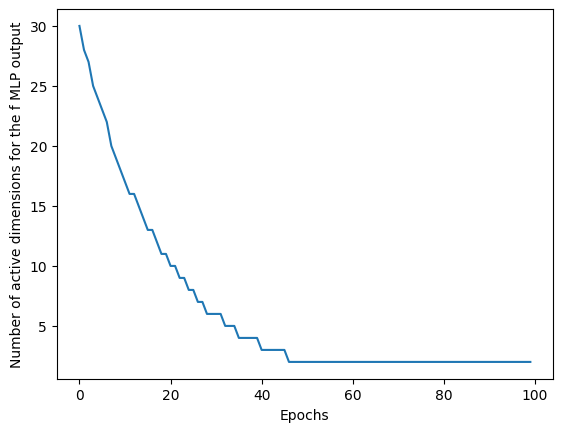

In [10]:
import matplotlib.pyplot as plt

plt.plot(active_dims)
plt.xlabel('Epochs')
plt.ylabel('Number of active dimensions for the f MLP output')
plt.show()

You can pass a `decay_rate` parameter into the `.set_schedule` method of a `Pruning_MLP`. The default is a cosine decay (as shown above). The other options are `exp` and `linear`. 

<img src="../_static/pruning_decay_schedules.png">
In the above image, the pruning finishes at epoch 75 and we prune 100 dimensions to 2 dimensions.

## Interpret the MLP

The `.distill` function only takes into account the active (non-masked) dimensions.

In [11]:
print("\nRunning symbolic regression on pruned f...")

sr_params = {'complexity_of_operators':  {"sin":3, "exp":3},
             'complexity_of_constants': 2, 
             'constraints': {"sin": 3, "exp":3},
             'parsimony': 0.01,
             'verbosity': 0, 
             'niterations': 100}

model.f_net.distill(torch.FloatTensor(X_train), 
                       sr_params=sr_params)


Running symbolic regression on pruned f...
🛠️ Running SR on active dimension 0 (1/2)


/Users/liz/PhD/SymTorch_project/symtorch_venv/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


💡Best equation for active dimension 0: ((x0 * x0) * -9.177365) + (sin(x4) * (x0 + 3.7915835)).
🛠️ Running SR on active dimension 21 (2/2)


/Users/liz/PhD/SymTorch_project/symtorch_venv/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


💡Best equation for active dimension 21: ((x0 * ((x4 * 0.02569695) + x0)) * 9.053295) + (sin(x4) * -4.9888153).
❤️ SR on f_net active dimensions complete.


{0: PySRRegressor.equations_ = [
 	    pick     score                                           equation  \
 	0         0.000000                                                 x4   
 	1         0.222776                                         -1.0853426   
 	2         0.308274                                     x0 * -3.806873   
 	3         0.058161                               inv(x0 + -1.1267803)   
 	4         0.431742                              x0 * (x0 * -5.707732)   
 	5         0.477709                       (x0 * -8.686444) + 3.2480958   
 	6         0.153751                      x4 + ((x0 * -6.5375166) * x0)   
 	7         0.544373                (x0 * -7.4334426) + (x4 * 4.868192)   
 	8         0.376226                ((x0 * x0) * -7.367284) + (x4 + x4)   
 	9         3.306437         ((x0 * x0) * -8.744584) + (x4 * 3.6595654)   
 	10        0.125803   (x4 * (x0 + 3.344076)) + (x0 * (x0 * -9.105152))   
 	11        0.138711  ((x4 * 3.3089917) + ((x4 + -10.204634) * (x0 

You can see that the outputs of the `f_net` NN are linear combinations of the f function.

In [16]:
model.f_net.show_symbolic_expression(dim=0)


➡️ Symbolic expressions for output dimension 0:
    complexity      loss                                           equation  \
0            1  9.869409                                                 x4   
1            2  7.898432                                         -1.0853426   
2            4  4.263609                                     x0 * -3.806873   
3            5  4.022708                               inv(x0 + -1.1267803)   
4            6  2.612253                              x0 * (x0 * -5.707732)   
5            7  1.620126                       (x0 * -8.686444) + 3.2480958   
6            8  1.389234                      x4 + ((x0 * -6.5375166) * x0)   
7            9  0.806041                (x0 * -7.4334426) + (x4 * 4.868192)   
8           10  0.553305                ((x0 * x0) * -7.367284) + (x4 + x4)   
9           11  0.020277         ((x0 * x0) * -8.744584) + (x4 * 3.6595654)   
10          13  0.015766   (x4 * (x0 + 3.344076)) + (x0 * (x0 * -9.105152))   
11 

We can even perform SR on the `g_net` to show that this layer is just a linear transformation of the inputs.\
Because `g_net` is an intermediate layer of the MLP, we need to pass in the `parent_model` (the whole model) to get the correct inputs to `g_net` for symbolic regression.

In [18]:
model.g_net = SymbolicModel(model.g_net, block_name='g_net')
model.g_net.distill(torch.FloatTensor(X_train), 
                     parent_model=model, # Pass in the parent_model because g_net is an intermediate layer
                     sr_params = sr_params)

🛠️ Running SR on output dimension 0 of 0


/Users/liz/PhD/SymTorch_project/symtorch_venv/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


💡Best equation for output 0 found to be (((x0 + 0.00012825789) * -0.104232065) + -0.0026094334) + (x21 * 0.17798738).
❤️ SR on g_net complete.


{0: PySRRegressor.equations_ = [
 	   pick         score                                           equation  \
 	0        0.000000e+00                                                x31   
 	1        8.785424e-02                                         0.24939868   
 	2        3.121439e+00                                    x21 * 0.2789512   
 	3        5.638493e-01                    (x21 * 0.27616408) + 0.03388125   
 	4        2.722068e+00           (x0 * -0.097962625) + (x21 * 0.18385741)   
 	5        3.338238e-07     (x0 * -0.09796284) + ((x12 + 0.1838572) * x21)   
 	6        1.949614e+01  ((x21 * 0.17798749) + (x0 * -0.10423195)) + -0...   
 	7        2.760529e-01  (x21 * 0.17798734) + ((x26 + (x0 * -0.10423212...   
 	8  >>>>  4.623406e-01  (((x0 + 0.00012825789) * -0.104232065) + -0.00...   
 	
 	           loss  complexity  
 	0  7.395062e-01           1  
 	1  6.773096e-01           2  
 	2  1.316859e-03           4  
 	3  2.426105e-04           7  
 	4  1.048458e-06       

The variables used in this NN are just the active dimensions of the `f_net` NN.

## Switch to Using the Equation Instead in the Forwards Pass

In [19]:
model.f_net.switch_to_symbolic() 

✅ Successfully switched f_net to symbolic equations for 2 active dimensions:
   Dimension 0: ((x0 * x0) * -9.177365) + (sin(x4) * (x0 + 3.7915835))
   Variables: ['x0', 'x4']
   Dimension 21: ((x0 * ((x4 * 0.02569695) + x0)) * 9.053295) + (sin(x4) * -4.9888153)
   Variables: ['x0', 'x4']
🎯 Active dimensions [0, 21] now using symbolic equations.
🔒 Inactive dimensions will output zeros.


In [20]:
model.g_net.switch_to_symbolic()

✅ Successfully switched g_net to symbolic equations for all 1 dimensions:
   Dimension 0: (((x0 + 0.00012825789) * -0.104232065) + -0.0026094334) + (x21 * 0.17798738)
   Variables: ['x0', 'x21']
🎯 All 1 output dimensions now using symbolic equations.


Now when running the forwards pass through the model, it uses the symbolic equation instead of the MLP. 

In [21]:
interpretable_outputs = model(torch.tensor(X_train, dtype=torch.float32))
interpretable_outputs

tensor([[-0.0244],
        [ 0.1939],
        [-0.4942],
        ...,
        [-0.7961],
        [ 1.8698],
        [ 1.2709]])

## Switch to Using the MLP in the Forwards Pass

In [22]:
model.f_net.switch_to_block()
model.g_net.switch_to_block()

✅ Switched f_net back to block
✅ Switched g_net back to block


In [23]:
model.eval()
with torch.no_grad():
    model_outputs = model(torch.tensor(X_train, dtype=torch.float32))
model_outputs

tensor([[-0.0293],
        [ 0.1937],
        [-0.4943],
        ...,
        [-0.7949],
        [ 1.8919],
        [ 1.2544]])

In [24]:
# Clean up 
import os
import shutil
if os.path.exists('SR_output'):
    shutil.rmtree('SR_output')
os.remove('model_weights.pth')